Libraries and helper functions:

In [ ]:
import sys
import os
sys.path.append(os.path.abspath('../..')) 

import numpy as np
import matplotlib.pyplot as plt
import pyroomacoustics as pra
from scipy.signal import lfilter

Simulation:

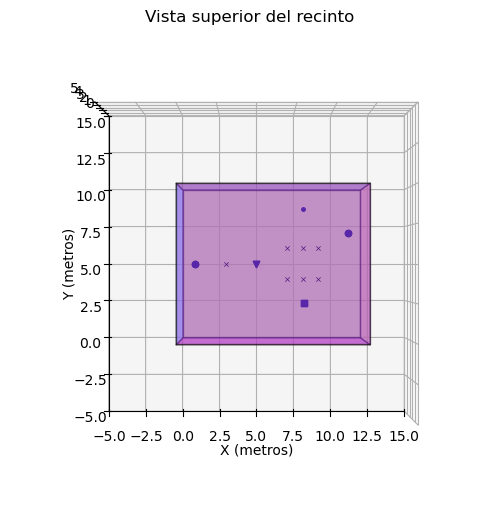

In [2]:
# Create a room
fs = 12000
room = pra.ShoeBox([12, 10, 5], fs=fs, max_order=0)

# Noise source
room.add_source([1, 5, 2.5])

# Reference microphones
room.add_microphone([3, 5, 2.5], fs=fs)

# Actuators
room.add_source([8, 2.5, 3.5])
room.add_source([5, 5, 2.5])
room.add_source([8, 8.5, 2.5])
room.add_source([11, 7, 1.5])

# Error microphones
room.add_microphone([7, 4, 2.5], fs=fs)
room.add_microphone([7, 6, 2.5], fs=fs)
room.add_microphone([8, 4, 2.5], fs=fs)
room.add_microphone([8, 6, 2.5], fs=fs)
room.add_microphone([9, 4, 2.5], fs=fs)
room.add_microphone([9, 6, 2.5], fs=fs)

fig, ax = room.plot()
ax.view_init(elev=90, azim=-90)
ax.set_title("Vista superior del recinto")
ax.set_xlim(-5, 15)
ax.set_ylim(-5, 15)
plt.grid(True)
plt.xlabel('X (metros)')
plt.ylabel('Y (metros)')
plt.show()

Obtain RIRs:

In [3]:
nReferenceMics = 1
nActuators = 4
nErrorMics = 6

room.compute_rir()
referencePaths = [room.rir[m][0] for m in range(nReferenceMics)]
primaryPaths = [room.rir[m][0] for m in range(nReferenceMics, nReferenceMics + nErrorMics)]
secondaryPaths = [[room.rir[m][s] for s in range(1, nActuators + 1)] for m in range(nReferenceMics, nReferenceMics + nErrorMics)]

# Shape RIRs for efficient convolution
referencePaths = np.array([
    np.pad(h, (0, max(len(h) for h in referencePaths) - len(h)))
    for h in referencePaths
])

primaryPaths = np.array([
    np.pad(h, (0, max(len(h) for h in primaryPaths) - len(h)))
    for h in primaryPaths
])

maxLen = max(len(h) for row in secondaryPaths for h in row)
secondaryPaths = np.array([
    [np.pad(h, (0, maxLen - len(h))) for h in row]
    for row in secondaryPaths
])

print("Reference paths shape: ", referencePaths.shape)
print("Primary paths shape: ", primaryPaths.shape)
print("Secondary paths shape: ", secondaryPaths.shape)

Reference paths shape:  (1, 152)
Primary paths shape:  (6, 365)
Secondary paths shape:  (6, 4, 261)


Algorithm (Section 4.5.4 of Elliot):

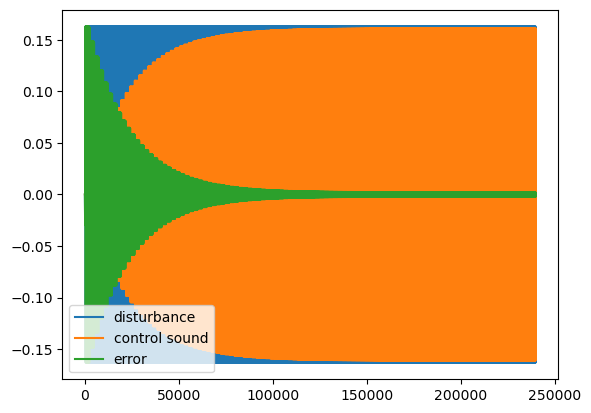

In [ ]:
# Calculate blocklength in order to have 10 cycles per block.
# Elliot states the controller expects steady state before each update.
toneFrequency = 50
offset = 0.0    # A very small offset kills the algorithm
samplesPerPeriod = int(fs / toneFrequency)
nPeriodsPerBlock = 10
blocklength = samplesPerPeriod * nPeriodsPerBlock

# Disturbance
nBlocks = 100
N = nBlocks * blocklength
t = np.arange(N) * (1/fs)
x = np.sin(2 * np.pi * (toneFrequency*(1 + offset)) * t)

# Generate the complex G matrix from plant model (ideal case where G = Ghat)
gHat = secondaryPaths
omega0 = 2 * np.pi * toneFrequency / fs
n = np.arange(gHat.shape[2])

gHatw0 = np.sum(
    gHat * np.exp(-1j * omega0 * n)[None, None, :],
    axis=2
)

# Calculate SVD of the plant model
R, singularValues, Qh = np.linalg.svd(
    gHatw0,
    full_matrices=True
)
Q = Qh.conj().T
v = np.zeros(nActuators, dtype=complex)

# Define the alpha vector
alpha = 0.1
#alphaVector = alpha * singularValues        # Steepest descent
#alphaVector = alpha * np.ones(nActuators)   # Principal coordinates with equal step for each mode
alphaVector = alpha / singularValues        # Newton

# States for online time domain convolution
pStates = np.zeros((nErrorMics, primaryPaths.shape[1] - 1))
sStates = np.zeros((nErrorMics, nActuators, secondaryPaths.shape[2] - 1))

# For testing
xRef = np.zeros((nReferenceMics, N))
d = np.zeros((nErrorMics, N))
u = np.zeros((nActuators, N))
y = np.zeros((nErrorMics, N))
e = np.zeros((nErrorMics, N))

for k in range(nBlocks):
    start = k * blocklength
    end = (k + 1) * blocklength

    # Block samples of X (simulation)
    xSignal = x[start : end]
    
    ################## Physical signals ##################
        
    # Disturbance signals (simulation)
    dSignals = np.zeros((nErrorMics, blocklength))
    for m in range(nErrorMics):
        dSignals[m], pStates[m] = lfilter(
            primaryPaths[m],
            [1],
            xSignal,            
            zi=pStates[m]
        )
        
    # Calculate physical phasors
    uPhasors = Q @ v

    # Generate actuator signals
    actuatorsSignals = np.zeros((nActuators, blocklength))
    for m in range(nActuators):
        actuatorsSignals[m] = np.real(
            uPhasors[m] * np.exp(1j * 2 * np.pi * toneFrequency * t[start : end])
        )
    
    # Control and Errors signals (simulation)
    controlSignals = np.zeros((nErrorMics, nActuators, blocklength))
    for nError in range(nErrorMics):
        for nActuator in range(nActuators):
            controlSignals[nError][nActuator], sStates[nError][nActuator] = lfilter(
                secondaryPaths[nError][nActuator],
                [1],
                actuatorsSignals[nActuator],
                zi=sStates[nError][nActuator]
            )
    controlSignals = np.sum(controlSignals, axis=1)

    errorSignals = dSignals + controlSignals

    ################## Algorithm ##################

    # Extract phasors from error vector
    n = np.arange(start, end)

    errorPhasors = (2 / blocklength) * np.sum(
        errorSignals * np.exp(-1j * omega0 * n)[None, :],
        axis=1
    )

    # Transform error vector into principal coordinates
    transformedErrorPhasors = R.conj().T @ errorPhasors

    # Adapt
    v = v - alphaVector * transformedErrorPhasors[:nActuators] 
    
    ################## For testing ##################
    start = k * blocklength
    end = (k + 1) * blocklength

    d[:, start:end] = dSignals
    y[:, start:end] = controlSignals
    e[:, start:end] = errorSignals

plt.plot(d[0], label="disturbance")
plt.plot(y[0], label="control sound")
plt.plot(e[0], label="error")
plt.legend()
plt.show()
